<a href="https://colab.research.google.com/github/09StevenG/2022-ii-tutorial-git-repo-ejemplo/blob/main/Semana_03_Practica_en_clase_Pandas_y_Geopandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
URL_ARCHIVO="https://raw.githubusercontent.com/navilaufm/python-curso-gis/refs/heads/main/estaciones_region.csv"

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv(URL_ARCHIVO) ##pandas

In [ ]:
df.head(5)

,codigo,nombre,pais,iso2,subregion,latitud,longitud,altitud_msnm,fecha_registro
0,MUCM,Camaguey/Agramonte A,Cuba,CU,Caribe,21.420,-77.850,124,2021-05-07
1,MUCC,Cayo Coco/Rey Arpt,Cuba,CU,Caribe,22.456,-78.339,2,2021-05-07
2,MUCL,Cayo Largo del Sur A,Cuba,CU,Caribe,21.621,-81.552,2,2021-05-07
3,MUCF,Cienfuegos/Gonzales,Cuba,CU,Caribe,22.159,-80.410,32,2021-05-07
4,MUGM,Guantanamo Bay(MIL),Cuba,CU,Caribe,19.909,-75.206,19,2021-05-07


In [ ]:
import geopandas as gpd

In [ ]:
#1 se carga primero el dato a df (pandas)
#2 se crea el geodataframe gdf indicándoles 2 cosas (los valores geográficos) y la el sistema de coordenadas
gdf = gpd.GeoDataFrame(df,  ###datos de la tabla
                       geometry=gpd.points_from_xy(df.longitud, df.latitud), #especificar las columnas que forman la geometría
                       crs="EPSG:4326") #obligatorio en qué están esa geometría

In [ ]:
gdf.head(5)

,codigo,nombre,pais,iso2,subregion,latitud,longitud,altitud_msnm,fecha_registro,geometry
0,MUCM,Camaguey/Agramonte A,Cuba,CU,Caribe,21.420,-77.850,124,2021-05-07,POINT (-77.85 21.42)
1,MUCC,Cayo Coco/Rey Arpt,Cuba,CU,Caribe,22.456,-78.339,2,2021-05-07,POINT (-78.339 22.456)
2,MUCL,Cayo Largo del Sur A,Cuba,CU,Caribe,21.621,-81.552,2,2021-05-07,POINT (-81.552 21.621)
3,MUCF,Cienfuegos/Gonzales,Cuba,CU,Caribe,22.159,-80.410,32,2021-05-07,POINT (-80.41 22.159)
4,MUGM,Guantanamo Bay(MIL),Cuba,CU,Caribe,19.909,-75.206,19,2021-05-07,POINT (-75.206 19.909)


<Axes: >

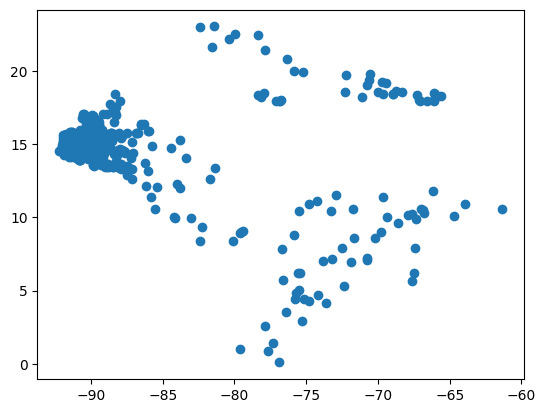

In [ ]:
gdf.plot() #inpeccionar que mi gdf tiene geometria

In [ ]:
gdf.estimate_utm_crs()

<Projected CRS: EPSG:32618>
Name: WGS 84 / UTM zone 18N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 78°W and 72°W, northern hemisphere between equator and 84°N, onshore and offshore. Bahamas. Canada - Nunavut; Ontario; Quebec. Colombia. Cuba. Ecuador. Greenland. Haiti. Jamaica. Panama. Turks and Caicos Islands. United States (USA). Venezuela.
- bounds: (-78.0, 0.0, -72.0, 84.0)
Coordinate Operation:
- name: UTM zone 18N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
gdf.to_csv('gdf_estaciones.csv') #extra los datos de gdf pero como archivo plano

In [ ]:
gdf.to_file("estaciones.geojson")

In [ ]:
gdf.to_file("estaciones.gpkg", layer="estaciones",driver="GPKG")

In [ ]:
#leer un archivo geográfico desde geopandas
URL_ARCHIVO_GEO="https://raw.githubusercontent.com/navilaufm/geodata/refs/heads/main/CA_ADM1.geojson"
gdf_adm1 = gpd.read_file(URL_ARCHIVO_GEO)

In [ ]:
gdf_adm1

,shapeName,shapeID,shapeGroup,shapeType,geometry
0,Orange Walk,66346737B60973332075708,BLZ,ADM1,"POLYGON ((-88.60466 18.24058, -88.61583 18.223..."
1,Corozal,66346737B23604924227645,BLZ,ADM1,"POLYGON ((-88.2949 17.97263, -88.17561 17.9529..."
2,Belize,66346737B58775340764376,BLZ,ADM1,"MULTIPOLYGON (((-87.78608 17.50981, -87.81174 ..."
3,Cayo,66346737B25506523624111,BLZ,ADM1,"POLYGON ((-89.15077 17.3318, -89.15016 17.0411..."
4,Stann Creek,66346737B48775360277934,BLZ,ADM1,"POLYGON ((-88.58481 17.10282, -88.60863 17.088..."
...,...,...,...,...,...
92,Provincia de Panamá Oeste,82927092B58639026682610,PAN,ADM1,"POLYGON ((-80.14244 8.94395, -80.13575 8.9181,..."
93,Provincia de Panamá,82927092B1953206585656,PAN,ADM1,"MULTIPOLYGON (((-79.10166 8.30988, -79.11444 8..."
94,Provincia de Veraguas,82927092B39170055747381,PAN,ADM1,"MULTIPOLYGON (((-81.78581 7.27389, -81.77003 7..."
95,Provincia de Chiriquí,82927092B1094181974383,PAN,ADM1,"MULTIPOLYGON (((-82.21034 8.26395, -82.21798 8..."


<Axes: >

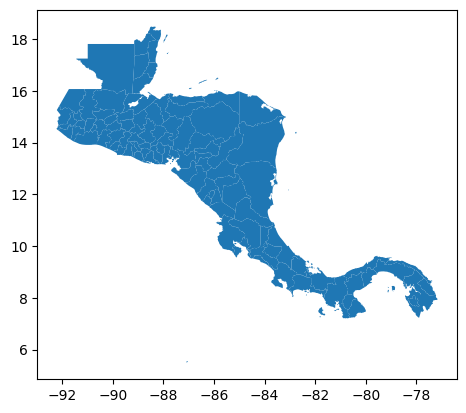

In [ ]:
gdf_adm1.plot()

In [ ]:
gdf_costarica=gdf_adm1[ (gdf_adm1["shapeGroup"] =="CRI")  ]

<Axes: >

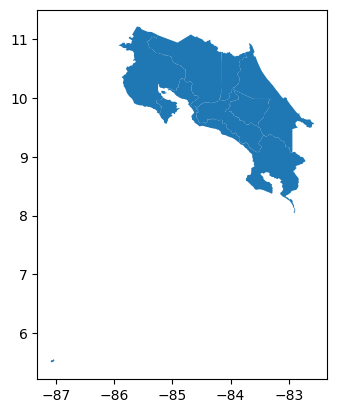

In [ ]:
gdf_costarica.plot()

In [ ]:
gdf_costarica

,shapeName,shapeID,shapeGroup,shapeType,geometry
6,Provincia Heredia,80129987B30917059240714,CRI,ADM1,"POLYGON ((-84.15559 10.78601, -84.16278 10.585..."
7,Provincia Guanacaste,80129987B99098477815223,CRI,ADM1,"POLYGON ((-85.25914 11.07796, -85.35747 11.126..."
8,Provincia Alajuela,80129987B16009817839121,CRI,ADM1,"POLYGON ((-84.15559 10.78601, -84.19077 10.789..."
9,Provincia San José,80129987B28144345958142,CRI,ADM1,"POLYGON ((-84.18354 9.972, -84.21248 9.96329, ..."
10,Provincia Puntarenas,80129987B82779638600484,CRI,ADM1,"MULTIPOLYGON (((-87.09425 5.51884, -87.07822 5..."
11,Provincia Cartago,80129987B41200343148036,CRI,ADM1,"POLYGON ((-83.5073 9.50047, -83.51225 9.53009,..."
12,Provincia Limón,80129987B40271573243189,CRI,ADM1,"POLYGON ((-83.93291 10.18725, -83.94717 10.146..."


In [ ]:
#vamos a ver las estaciones en un explore de geopandas
gdf.explore( tiles="https://tile.openstreetmap.de/{z}/{x}/{y}.png",
    attr='&copy; <a href="https://opentopomap.org">OpenTopoMap</a> contributors',
    marker_kwds={"radius" : 5})

In [ ]:
#vamos a ver las estaciones en un explore de geopandas
gdf_costarica.explore( tiles="https://tile.openstreetmap.de/{z}/{x}/{y}.png",
    attr='&copy; <a href="https://opentopomap.org">OpenTopoMap</a> contributors',
    marker_kwds={"radius" : 5})

In [ ]:
#usando explore para ver el gdf_adm1
gdf_adm1.explore(tiles="https://tile.openstreetmap.de/{z}/{x}/{y}.png",
    attr='&copy; <a href="https://opentopomap.org">OpenTopoMap</a> contributors',
                 color="black")

In [ ]:
#leer /content/estaciones.geojson directo a un gdf y plotarlo con explore
gdf_estaciones_geojson = gpd.read_file("/content/estaciones.geojson")

In [ ]:
gdf_estaciones_geojson.explore(tiles="https://tile.openstreetmap.de/{z}/{x}/{y}.png",
    attr='&copy; <a href="https://opentopomap.org">OpenTopoMap</a> contributors',
                 color="red", marker_kwds={"radius" : 5})